# Sports Ball Classification Using Support Vector Machines
This program classifies images of sports balls using a Support Vector Machine (SVM) model.

## Loading the dataset
The following aproach assumes that the dataset folder "archive (sport Balls)" is always in "Project" folder which is a sibling of the "Notebooks" folder.

In [1]:
import os
import cv2  # for image processing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder


# Get the current notebook directory
notebook_dir = os.getcwd()
# Navigate to the "Project" folder)
project_dir = os.path.join(os.path.dirname(notebook_dir), 'Project')
# Construct paths to the dataset
dataset_dir = os.path.join(project_dir, 'archive (sport Balls)')
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'test')
# Print the paths for verification
print(f"notebook_dir: {notebook_dir}")
print(f"Project_dir: {project_dir}")
print(f"Training path: {train_path}")
print(f"Testing path: {test_path}")

notebook_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Notebooks
Project_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Project
Training path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\train
Testing path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\test


In [3]:
image_size = (64, 64)  # Resize images for consistency

# preparing the dataset by loading the images and their labels from the dataset folder structure.
def load_images_from_folder(folder_path):
    #Initialise empty lists
    images = []
    labels = []
    #Loop through folders
    for label in os.listdir(folder_path):
        #create the path to the current subfolder
        label_path = os.path.join(folder_path, label)
        #Check if it’s a folder
        if os.path.isdir(label_path):  # Skip non-directory files if any
            #Loop through each image in the subfolder
            for filename in os.listdir(label_path):                
                img_path = os.path.join(label_path, filename) #For each file in the subfolder
                image = cv2.imread(img_path) # loads the image into memory using OpenCV.
                #Store valid images
                if image is not None: #checks if the image was loaded successfully.
                    image = cv2.resize(image, image_size)  # Resize to (64, 64)
                    images.append(image)
                    labels.append(label)                    
    return np.array(images), np.array(labels)

# Load images
print("Loading training data...")
train_images, train_labels = load_images_from_folder(train_path)
print("Loading testing data...")
test_images, test_labels = load_images_from_folder(test_path)

# Check shapes
print("Train image shapes:", {img.shape for img in train_images})
print("Test image shapes:", {img.shape for img in test_images})


Loading training data...
Loading testing data...
Train image shapes: {(64, 64, 3)}
Test image shapes: {(64, 64, 3)}


In [4]:
# Flatten images
train_images = train_images.reshape(len(train_images), -1)
test_images = test_images.reshape(len(test_images), -1)

# Check shapes after flatening
print("Train image shapes after flatening:", train_images.shape)
print("Test image shapes after flatening:", test_images.shape)

# Scale features for PCA
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images)
test_images_scaled = scaler.transform(test_images)

# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=0.95)  # Retain 95% of the variance
train_images_pca = pca.fit_transform(train_images_scaled)
test_images_pca = pca.transform(test_images_scaled)

print(f"Number of PCA components: {pca.n_components_}")

# Check shapes after PCA
print("Train image shapes after PCA:", train_images_pca.shape)
print("Test image shapes after PCA:", test_images_pca.shape)

# Convert the text labels (ball types) to numerical format using LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

Train image shapes after flatening: (7328, 12288)
Test image shapes after flatening: (1841, 12288)
Applying PCA...
Number of PCA components: 916
Train image shapes after PCA: (7328, 916)
Test image shapes after PCA: (1841, 916)


## Hyperparameter optimization
Hyperparameter optimization is performed using GridSearchCV, which systematically searches through all possible combinations of C, gamma, and kernel parameters.Each combination is assessed using 5-fold cross-validation, and the best set of hyperparameters is determined based on cross-validation accuracy.

In [5]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.5,1, 10, 20],
    'degree': [4, 5, 6],
    'gamma': ['scale'],
    'coef0': [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(SVC(kernel='poly'), param_grid, cv=5, scoring='accuracy',n_jobs=-1, verbose = 1)
grid_search.fit(train_images_pca, train_labels_encoded)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate the best model
best_model = grid_search.best_estimator_
test_predictions = best_model.predict(test_images_pca)
accuracy = accuracy_score(test_labels_encoded, test_predictions)
print(f"Test Accuracy with Best Model: {accuracy * 100:.2f}%")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 0.5, 'coef0': 1, 'degree': 6, 'gamma': 'scale'}
Test Accuracy with Best Model: 49.00%


In [6]:
# Initialize and train the SVM classifier
print("Training SVM...")
svm_model = SVC(kernel='poly', C=0.5, degree=6, gamma='scale', coef0=1)  
svm_model.fit(train_images_pca, train_labels_encoded)

# Predict on test data
print("Evaluating the model...")
test_predictions = svm_model.predict(test_images_pca)

# Calculate accuracy
accuracy = accuracy_score(test_labels_encoded, test_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print(classification_report(test_labels_encoded, test_predictions, target_names=label_encoder.classes_))


Training SVM...
Evaluating the model...
Accuracy: 49.00%
                   precision    recall  f1-score   support

american_football       0.53      0.53      0.53        96
         baseball       0.33      0.46      0.39       100
       basketball       0.42      0.43      0.43        86
    billiard_ball       0.54      0.48      0.51       162
     bowling_ball       0.41      0.41      0.41       111
     cricket_ball       0.54      0.51      0.52       146
         football       0.48      0.46      0.47       151
        golf_ball       0.40      0.51      0.45       138
      hockey_ball       0.44      0.44      0.44       133
      hockey_puck       0.52      0.45      0.48        98
       rugby_ball       0.60      0.61      0.61       124
      shuttlecock       0.55      0.52      0.54       108
table_tennis_ball       0.47      0.57      0.52       156
      tennis_ball       0.67      0.58      0.62       123
       volleyball       0.56      0.31      0.40       10

The SVM model with the best hyperparameters and PCA achieves moderate performance, with an overall accuracy of 49.00%. While it performs well for certain distinct classes (e.g., rugby ball, tennis ball), the model struggles with overlapping classes like basketball and volleyball.

### Class Distribution in Training and Test Sets
The following plot shows how many images are present for each class (ball type) in the training and test sets.
It helps to check for class balance. If certain ball types are underrepresented, the model might struggle to learn to classify those types correctly, leading to poor performance or bias towards more frequent classes. Identifying this early allows to take steps like collecting more images or applying techniques to balance the dataset.

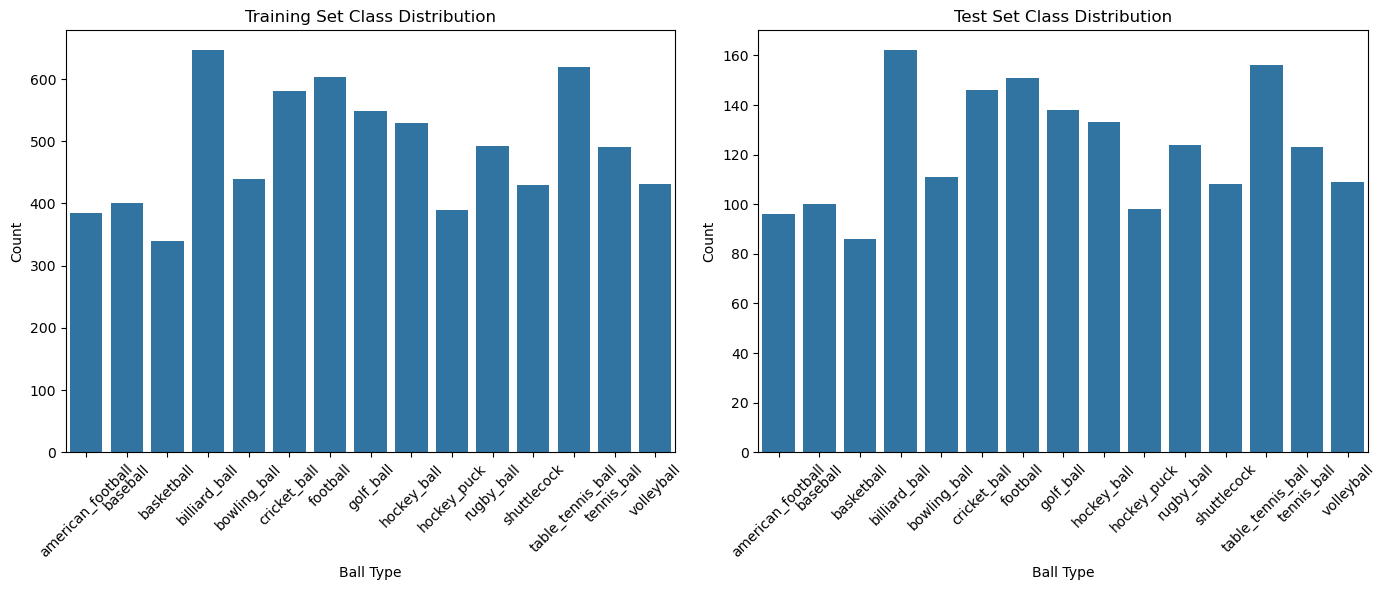

In [11]:
# Count the number of images per class in train and test sets
train_counts = np.unique(train_labels, return_counts=True)
test_counts = np.unique(test_labels, return_counts=True)

# Plot the distributions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=train_counts[0], y=train_counts[1])
plt.title('Training Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=test_counts[0], y=test_counts[1])
plt.title('Test Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [12]:
from collections import Counter
def imbalance_ratio(class_counts):
    max_count = max(class_counts.values())
    min_count = min(class_counts.values())
    return max_count / min_count

# Function to assess balance
def assess_balance(imbalance_ratio, dataset_name):
    if imbalance_ratio <= 1.5:
        print(f"{dataset_name} is balanced.")
    elif imbalance_ratio <= 3:
        print(f"{dataset_name} is moderately imbalanced.")
    else:
        print(f"{dataset_name} is highly imbalanced.")
        # Analyze class distribution
train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

print("\nTraining Class Distribution:")
for label, count in train_class_counts.items():
    print(f"Class '{label}': {count} samples")

print("\nTesting Class Distribution:")
for label, count in test_class_counts.items():
    print(f"Class '{label}': {count} samples")

# Compute and print imbalance ratios
train_imbalance_ratio = imbalance_ratio(train_class_counts)
test_imbalance_ratio = imbalance_ratio(test_class_counts)

print(f"\nTraining Set Imbalance Ratio: {train_imbalance_ratio:.2f}")
print(f"Testing Set Imbalance Ratio: {test_imbalance_ratio:.2f}")

# Assess balance
assess_balance(train_imbalance_ratio, "Training Set")
assess_balance(test_imbalance_ratio, "Testing Set")


Training Class Distribution:
Class 'american_football': 384 samples
Class 'baseball': 400 samples
Class 'basketball': 340 samples
Class 'billiard_ball': 646 samples
Class 'bowling_ball': 440 samples
Class 'cricket_ball': 581 samples
Class 'football': 604 samples
Class 'golf_ball': 549 samples
Class 'hockey_ball': 530 samples
Class 'hockey_puck': 390 samples
Class 'rugby_ball': 493 samples
Class 'shuttlecock': 429 samples
Class 'table_tennis_ball': 620 samples
Class 'tennis_ball': 490 samples
Class 'volleyball': 432 samples

Testing Class Distribution:
Class 'american_football': 96 samples
Class 'baseball': 100 samples
Class 'basketball': 86 samples
Class 'billiard_ball': 162 samples
Class 'bowling_ball': 111 samples
Class 'cricket_ball': 146 samples
Class 'football': 151 samples
Class 'golf_ball': 138 samples
Class 'hockey_ball': 133 samples
Class 'hockey_puck': 98 samples
Class 'rugby_ball': 124 samples
Class 'shuttlecock': 108 samples
Class 'table_tennis_ball': 156 samples
Class 'te

The analysis of class distributions in the training and test datasets reveals that both sets are moderately imbalanced, with imbalance ratios of 1.90 for the training set and 1.88 for the test set. This means the largest class has approximately 1.9 times more samples than the smallest class. While not severely imbalanced, this level of imbalance can still influence model performance, especially in terms of recall for underrepresented classes.

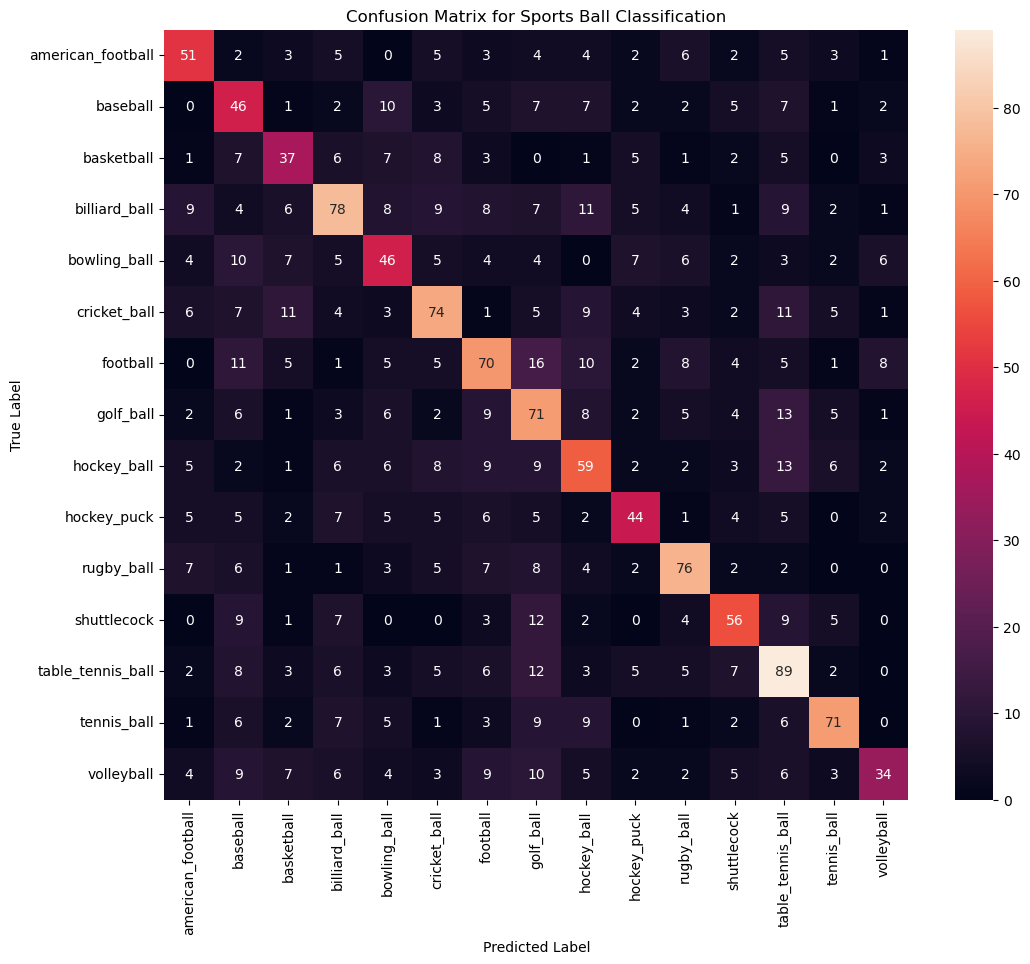

In [9]:
# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels_encoded, test_predictions)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Sports Ball Classification")
plt.show()

The confusion matrix shows that the model performs reasonably well across most classes, as indicated by the strong diagonal values representing correct predictions. For example, classes like billiard_ball (78/162), rugby_ball (76/124), table_tennis_ball (89/156), and tennis_ball (71/123) have the highest diagonal counts, reflecting a relatively high true positive rate compared to their respective class sizes in the test set. This suggests that the model successfully identifies these classes despite moderate imbalance in the data.

However, some challenges arise for classes like baseball (46/100) and basketball (37/86), where the correct predictions are notably lower compared to the total samples. Misclassifications are spread across visually similar classes, such as basketball being confused with billiard_ball and baseball. This trend could be attributed to insufficient discriminatory features or overlap in the visual patterns of these sports balls.

The off-diagonal values remain relatively low (mostly below 16 counts), indicating that errors are somewhat controlled but still persistent, particularly for underperforming classes. Given the imbalance in the testing distribution, where some classes like billiard_ball and table_tennis_ball have far more samples than others, the model's performance appears skewed towards majority classes.

### Learning Curve
This plot shows the model’s accuracy on the training and validation sets as the size of the training set increases.
This helps to understand if the model is underfitting, overfitting, or has potential for improvement.

[learning_curve] Training set sizes: [ 586  963 1339 1716 2093 2470 2847 3224 3600 3977 4354 4731 5108 5485
 5862]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:  3.9min finished


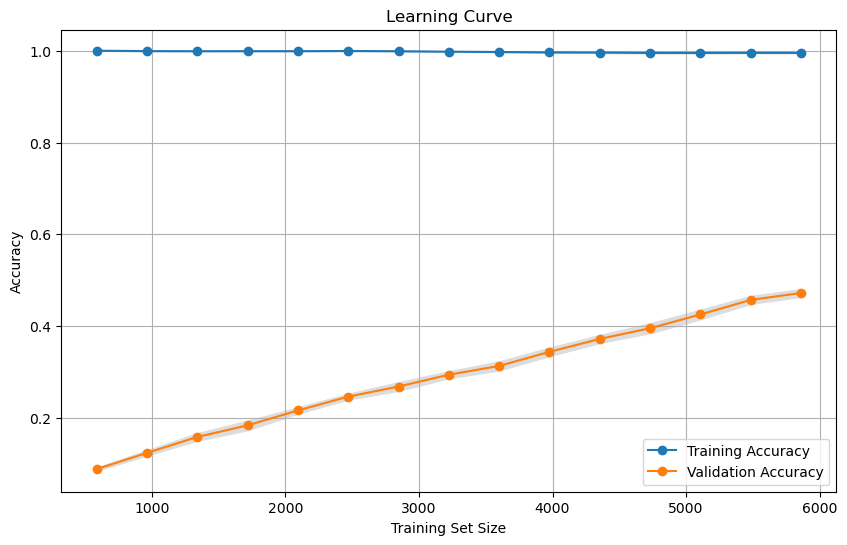

In [15]:
# Compute the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='poly', C=0.5, degree=6, gamma='scale', coef0=1),  
    train_images_pca, train_labels_encoded, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy', 
    n_jobs=-1,  # Use all available processors
    train_sizes=np.linspace(0.1, 1.0, 15), 
    verbose = 1,
)

# Calculate the mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', marker='o')
plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy', marker='o')

# Add shaded areas for standard deviation
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color = '#DDDDDD')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, color = '#DDDDDD')

# Plot formatting
plt.title('Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The learning curve shows that the training accuracy remains constant at 1.0, which is expected in SVMs. This reflects the model's ability to perfectly fit the training data. However, the validation accuracy increases linearly without fluctuation, suggesting that the model is learning but still struggles to generalize effectively. Adding more training data could help the validation accuracy stabilize (stagnate) by providing the model with more examples to generalize better.

###  Precision-Recall Curve (for each Class)
For each class, this curve shows the trade-off between precision (correct positive predictions among all positive predictions) and recall (correct positive predictions among all actual positives) at different decision thresholds.
This curve helps evaluate the model’s performance on each class, particularly for imbalanced datasets. High precision indicates fewer false positives, while high recall indicates fewer false negatives.

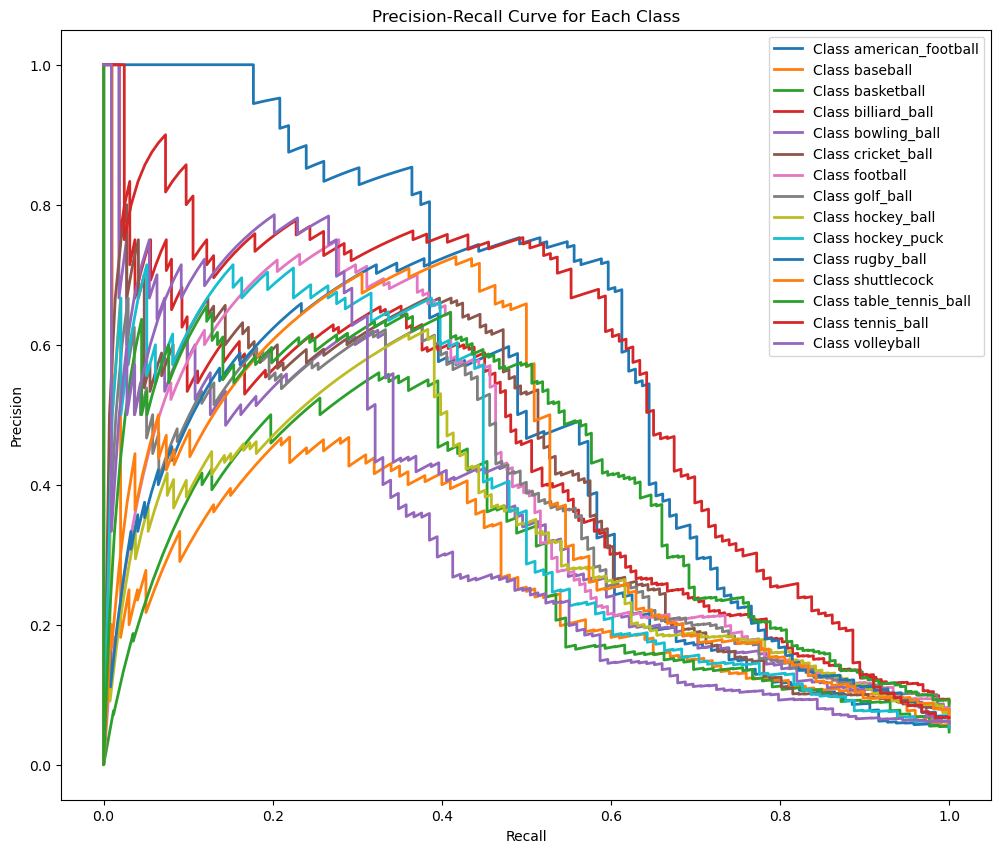

In [17]:
# Binarize labels for precision-recall curve plotting
y_test_bin = label_binarize(test_labels_encoded, classes=np.arange(len(np.unique(test_labels_encoded))))
y_scores = svm_model.decision_function(test_images_pca)  # decision_function gives scores to plot precision-recall

plt.figure(figsize=(12, 10))
for i in range(len(np.unique(test_labels_encoded))):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {label_encoder.inverse_transform([i])[0]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc='best')
plt.show()

## Impact of PCA Variance Retention on Model Performance

In [7]:
import time

# Variance levels to evaluate
variance_levels = [0.70,0.85, 0.95, 0.99]
results = []

for variance in variance_levels:
    # Start timing
    start_time = time.time()
    # Apply PCA
    pca = PCA(n_components=variance)
    train_images_pca = pca.fit_transform(train_images_scaled)
    test_images_pca = pca.transform(test_images_scaled)
    
    # Train SVM model
    svm_model = SVC(kernel='poly', C=0.5, degree=6, gamma='scale', coef0=1)
    svm_model.fit(train_images_pca, train_labels_encoded)
    
    # End timing
    end_time = time.time()
    
    # Evaluate accuracy
    test_predictions = svm_model.predict(test_images_pca)
    accuracy = accuracy_score(test_labels_encoded, test_predictions)
    
    # Store results
    time_taken = end_time - start_time
    results.append((variance, accuracy, time_taken))

# Display results
print("Variance Retention | Test Accuracy (%) | Computation Time (s)")
for var, acc, t in results:
    print(f"{var*100:.0f}%                | {acc*100:.2f}         | {t:.2f}")


Variance Retention | Test Accuracy (%) | Computation Time (s)
70%                | 41.23         | 88.79
85%                | 48.94         | 88.89
95%                | 49.00         | 97.26
99%                | 49.21         | 119.28


While increasing the variance retention in PCA improves the model's accuracy, the results demonstrate diminishing returns beyond 95%. For example, retaining 95% variance achieves an accuracy of 49.00% with a computation time of 97.26 seconds, whereas increasing to 99% variance only improves accuracy marginally to 49.21% but incurs a significant increase in computation time to 119.28 seconds. This highlights that the additional computational cost does not yield a proportionate improvement in performance.

In contrast, reducing the variance retention to 85% results in a slight decrease in accuracy to 48.94% while maintaining similar computation time as 95%. Retaining only 70% variance leads to a substantial drop in accuracy to 41.23%, indicating that too much dimensionality reduction compromises the model’s ability to capture meaningful patterns.

Based on these results, retaining 95% variance strikes an optimal balance, preserving sufficient information for classification while avoiding unnecessary computational overhead. This choice ensures that the dimensionality reduction is effective without sacrificing either accuracy or efficiency.